# IDX EDA

**Goal:** Load at least 6 months of CRMLS *Sold* listings, restrict to
single-family homes, and explore the distributions of the target variable
(`ClosePrice`) and the core property attributes (`LivingArea`, `Bedrooms`,
`Bathrooms`, `LotSize`).

**Scope (per task doc):**
- `PropertyType == "Residential"`
- `PropertySubType == "SingleFamilyResidence"`

**Data:** six monthly extracts, `CRMLSSold202512.csv` … `CRMLSSold202605.csv`
(Dec 2025 – May 2026).


## Setup

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


## Load 6 months of data

The six monthly CSVs share an identical 78-column schema, so we read each and
concatenate. `DATA_DIR` auto-detects whether the CSVs sit next to the notebook
or in the parent folder.

In [2]:
def find_data_dir():
    for cand in [Path("."), Path(".."), Path("../..")]:
        if sorted(cand.glob("CRMLSSold*.csv")):
            return cand
    raise FileNotFoundError("Could not locate CRMLSSold*.csv files.")

DATA_DIR = find_data_dir()
files = sorted(DATA_DIR.glob("CRMLSSold*.csv"))
print(f"Found {len(files)} files in '{DATA_DIR.resolve()}':")
for f in files:
    print("  ", f.name)


Found 6 files in '/sessions/optimistic-pensive-rubin/mnt/IDXdata':
   CRMLSSold202512.csv
   CRMLSSold202601.csv
   CRMLSSold202602.csv
   CRMLSSold202603.csv
   CRMLSSold202604.csv
   CRMLSSold202605.csv


In [3]:
frames = []
for f in files:
    part = pd.read_csv(f, low_memory=False)
    part["source_file"] = f.name
    frames.append(part)

raw = pd.concat(frames, ignore_index=True)
print(f"Combined shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw[["source_file"]].value_counts()


Combined shape: 124,404 rows x 79 columns


source_file        
CRMLSSold202604.csv    23412
CRMLSSold202605.csv    23260
CRMLSSold202603.csv    22583
CRMLSSold202512.csv    20538
CRMLSSold202602.csv    18124
CRMLSSold202601.csv    16487
Name: count, dtype: int64

Confirm the time span actually covers ~6 months using `CloseDate`.

In [4]:
raw["CloseDate"] = pd.to_datetime(raw["CloseDate"], errors="coerce")
print("CloseDate range:", raw["CloseDate"].min().date(), "->", raw["CloseDate"].max().date())
raw["CloseDate"].dt.to_period("M").value_counts().sort_index()


CloseDate range: 2025-12-01 -> 2026-05-31


CloseDate
2025-12    20538
2026-01    16487
2026-02    18124
2026-03    22583
2026-04    23412
2026-05    23260
Freq: M, Name: count, dtype: int64

## Restrict to single-family residential

Per the task doc we keep only `PropertyType == "Residential"` and
`PropertySubType == "SingleFamilyResidence"`.

In [5]:
print("PropertyType:")
print(raw["PropertyType"].value_counts(dropna=False).head(10), "\n")
print("PropertySubType (top 10):")
print(raw["PropertySubType"].value_counts(dropna=False).head(10))


PropertyType:
PropertyType
Residential            82643
ResidentialLease       29673
Land                    4012
ResidentialIncome       3381
ManufacturedInPark      3186
CommercialSale           805
CommercialLease          638
BusinessOpportunity       66
Name: count, dtype: int64 

PropertySubType (top 10):
PropertySubType
SingleFamilyResidence    75250
Condominium              21716
NaN                       9185
Townhouse                 7207
Apartment                 3431
Duplex                    2505
ManufacturedOnLand        1227
Triplex                    854
Quadruplex                 786
MixedUse                   473
Name: count, dtype: int64


In [6]:
mask = (raw["PropertyType"] == "Residential") & (raw["PropertySubType"] == "SingleFamilyResidence")
df = raw.loc[mask].copy()
print(f"After filter: {len(df):,} rows "
      f"({len(df)/len(raw):.1%} of combined data)")


After filter: 61,727 rows (49.6% of combined data)


In [7]:
cols = {
    "ClosePrice": "ClosePrice",
    "LivingArea": "LivingArea",
    "BedroomsTotal": "Bedrooms",
    "BathroomsTotalInteger": "Bathrooms",
    "LotSizeSquareFeet": "LotSize",
}
eda = df[list(cols)].rename(columns=cols)
for c in eda.columns:
    eda[c] = pd.to_numeric(eda[c], errors="coerce")
eda.head()


,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
0,"1,998,000.00","2,045.00",4.00,2.00,"10,080.00"
2,"2,214,421.00","3,050.00",4.00,4.00,"34,745.00"
3,"1,200,000.00","1,594.00",4.00,2.00,"6,600.00"
7,"3,100,000.00","2,700.00",5.00,3.00,"8,262.00"
9,"2,900,000.00","2,948.00",5.00,4.00,"9,222.00"


### Missingness and summary statistics

In [8]:
miss = eda.isna().mean().mul(100).round(2).rename("% missing")
display(miss.to_frame())
eda.describe().T


,% missing
ClosePrice,0.00
LivingArea,0.05
Bedrooms,0.00
Bathrooms,0.00
LotSize,1.75


,count,mean,std,min,25%,50%,75%,max
ClosePrice,"61,727.00","1,340,106.06","7,307,628.93",1.75,"620,000.00","890,000.00","1,425,000.00","796,000,000.00"
LivingArea,"61,697.00","2,055.55","1,037.24",0.00,"1,386.00","1,826.00","2,455.00","23,314.00"
Bedrooms,"61,727.00",3.50,0.97,0.00,3.00,3.00,4.00,22.00
Bathrooms,"61,726.00",2.64,1.14,0.00,2.00,2.00,3.00,22.00
LotSize,"60,646.00","385,948.90","18,434,009.61",0.00,"5,663.00","7,263.50","10,454.00","1,897,473,600.00"


The raw summary reveals heavy right-skew and implausible extremes
(e.g. `ClosePrice` in the hundreds of millions, `LivingArea` of 0, enormous
`LotSize` values from acreage parcels). We therefore look at distributions
**both raw and on cleaned/clipped views** so a handful of outliers don't hide
the shape of the bulk of the market.

## Distribution of the target — `ClosePrice`

Prices span several orders of magnitude, so we show the raw distribution,
a version clipped to the 1st–99th percentile, and a log-scale view.

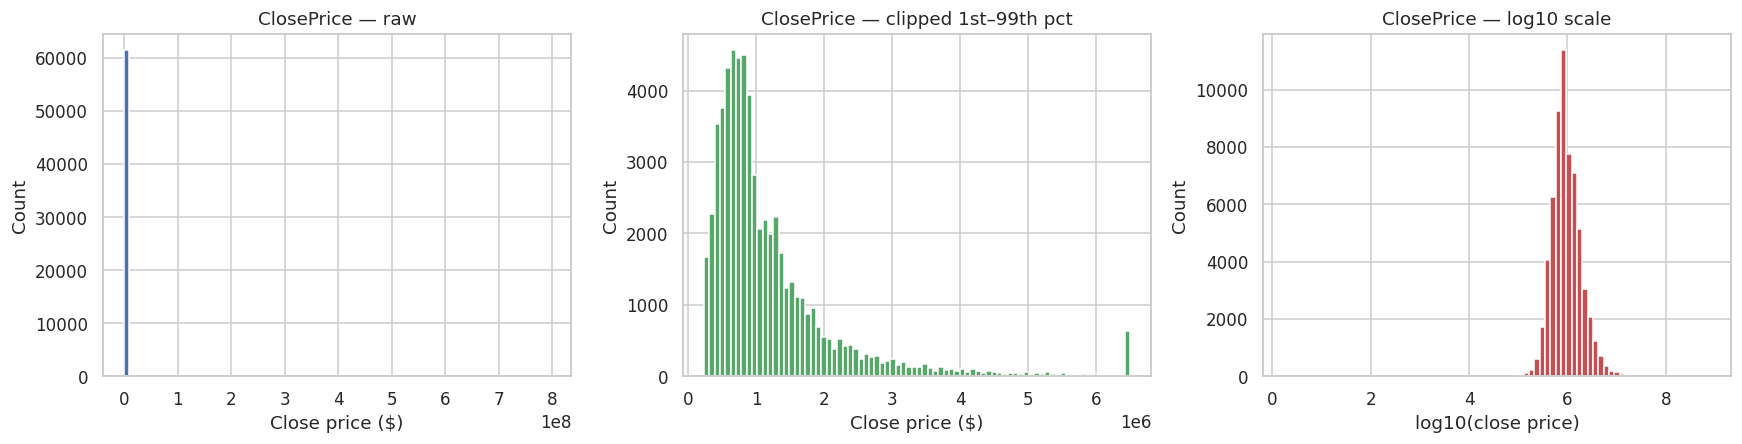

Median close price: $890,000
Mean close price:   $1,340,106
1st–99th pct:       $230,000  –  $6,500,000


In [9]:
price = eda["ClosePrice"].dropna()
price = price[price > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].hist(price, bins=80, color="#4C72B0")
axes[0].set_title("ClosePrice — raw")
axes[0].set_xlabel("Close price ($)")

lo, hi = price.quantile([0.01, 0.99])
axes[1].hist(price.clip(lo, hi), bins=80, color="#55A868")
axes[1].set_title("ClosePrice — clipped 1st–99th pct")
axes[1].set_xlabel("Close price ($)")

axes[2].hist(np.log10(price), bins=80, color="#C44E52")
axes[2].set_title("ClosePrice — log10 scale")
axes[2].set_xlabel("log10(close price)")

for ax in axes:
    ax.set_ylabel("Count")
fig.tight_layout()
plt.show()

print(f"Median close price: ${price.median():,.0f}")
print(f"Mean close price:   ${price.mean():,.0f}")
print(f"1st–99th pct:       ${lo:,.0f}  –  ${hi:,.0f}")


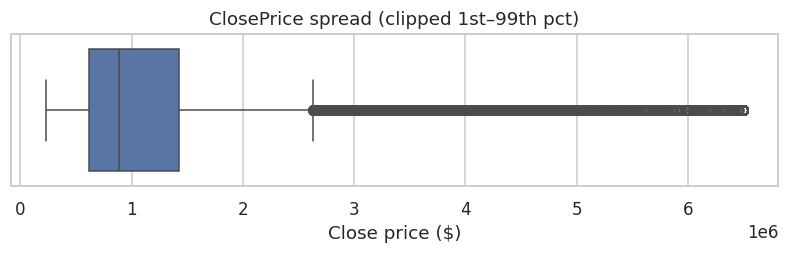

In [10]:
fig, ax = plt.subplots(figsize=(9, 1.8))
sns.boxplot(x=price.clip(*price.quantile([0.01, 0.99])), color="#4C72B0", ax=ax)
ax.set_title("ClosePrice spread (clipped 1st–99th pct)")
ax.set_xlabel("Close price ($)")
plt.show()


## `LivingArea`

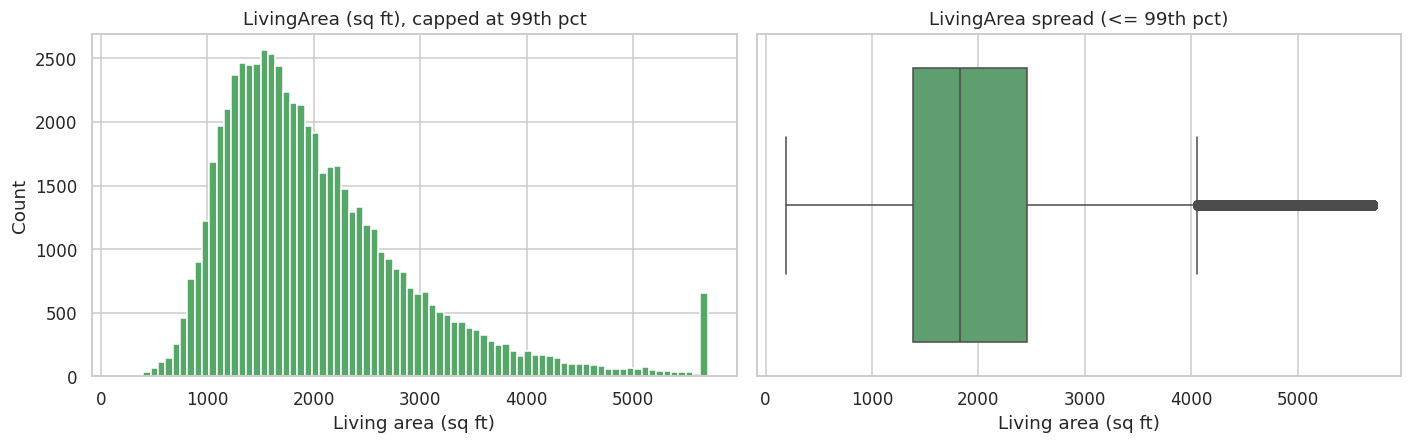

count   61,678.00
mean     2,056.00
std      1,037.00
min        192.00
25%      1,386.00
50%      1,826.00
75%      2,455.00
max     23,314.00
Name: LivingArea, dtype: float64


In [11]:
la = eda["LivingArea"].dropna()
la = la[(la > 0)]
hi = la.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(la.clip(upper=hi), bins=80, color="#55A868")
axes[0].set_title("LivingArea (sq ft), capped at 99th pct")
axes[0].set_xlabel("Living area (sq ft)")
axes[0].set_ylabel("Count")

sns.boxplot(x=la.clip(upper=hi), color="#55A868", ax=axes[1])
axes[1].set_title("LivingArea spread (<= 99th pct)")
axes[1].set_xlabel("Living area (sq ft)")
fig.tight_layout()
plt.show()
print(la.describe().round(0))


## `Bedrooms` and `Bathrooms`\n\nThese are effectively discrete counts, so count plots are clearer than histograms.

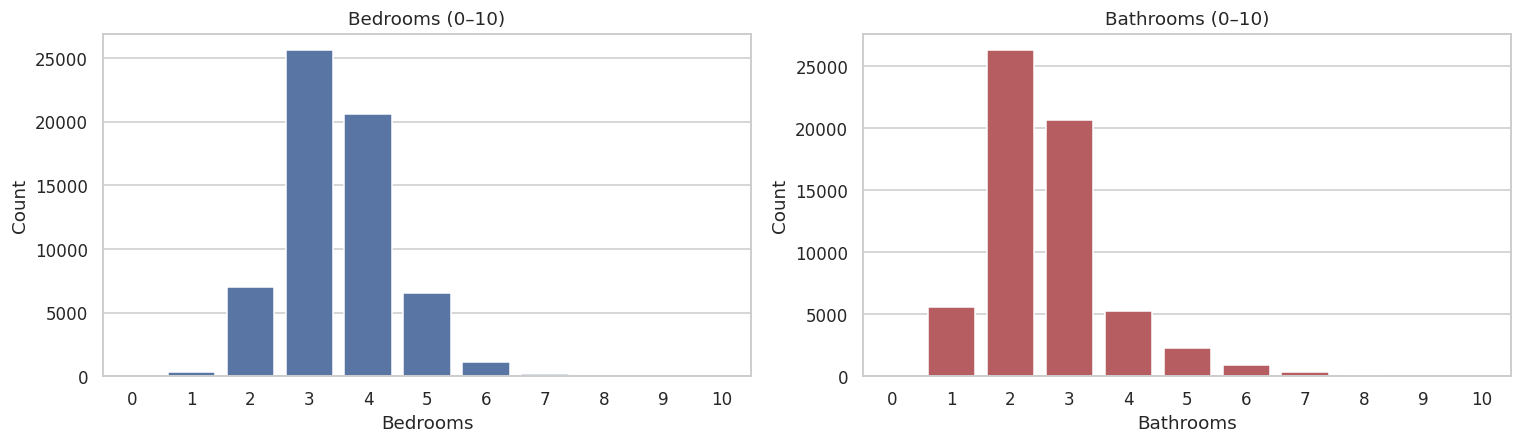

Bedrooms summary:
 count   61,727.00
mean         3.50
std          0.97
min          0.00
25%          3.00
50%          3.00
75%          4.00
max         22.00
Name: Bedrooms, dtype: float64 

Bathrooms summary:
 count   61,726.00
mean         2.64
std          1.14
min          0.00
25%          2.00
50%          2.00
75%          3.00
max         22.00
Name: Bathrooms, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

bed = eda["Bedrooms"].dropna()
bed = bed[(bed >= 0) & (bed <= 10)]
sns.countplot(x=bed.astype(int), color="#4C72B0", ax=axes[0])
axes[0].set_title("Bedrooms (0–10)")
axes[0].set_xlabel("Bedrooms")
axes[0].set_ylabel("Count")

bath = eda["Bathrooms"].dropna()
bath = bath[(bath >= 0) & (bath <= 10)]
sns.countplot(x=bath.astype(int), color="#C44E52", ax=axes[1])
axes[1].set_title("Bathrooms (0–10)")
axes[1].set_xlabel("Bathrooms")
axes[1].set_ylabel("Count")

fig.tight_layout()
plt.show()
print("Bedrooms summary:\n", eda["Bedrooms"].describe().round(2), "\n")
print("Bathrooms summary:\n", eda["Bathrooms"].describe().round(2))


## `LotSize`

Lot sizes are extremely right-skewed (small urban lots up to large acreage
parcels), so we view the typical range (clipped at the 99th percentile) and a
log-scale view.

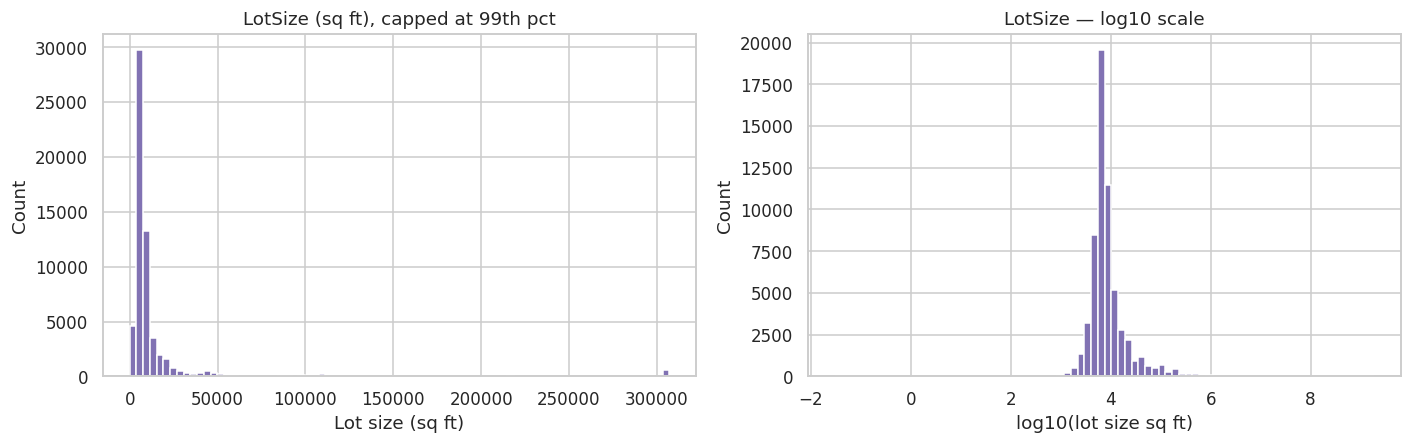

count          60,602.00
mean          386,229.00
std        18,440,698.00
min                 0.00
25%             5,663.00
50%             7,270.00
75%            10,454.00
max     1,897,473,600.00
Name: LotSize, dtype: float64


In [13]:
lot = eda["LotSize"].dropna()
lot = lot[lot > 0]
hi = lot.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(lot.clip(upper=hi), bins=80, color="#8172B3")
axes[0].set_title("LotSize (sq ft), capped at 99th pct")
axes[0].set_xlabel("Lot size (sq ft)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log10(lot), bins=80, color="#8172B3")
axes[1].set_title("LotSize — log10 scale")
axes[1].set_xlabel("log10(lot size sq ft)")
axes[1].set_ylabel("Count")
fig.tight_layout()
plt.show()
print(lot.describe().round(0))


## Relationships with the target\n\nA quick look at how the main drivers relate to `ClosePrice`.

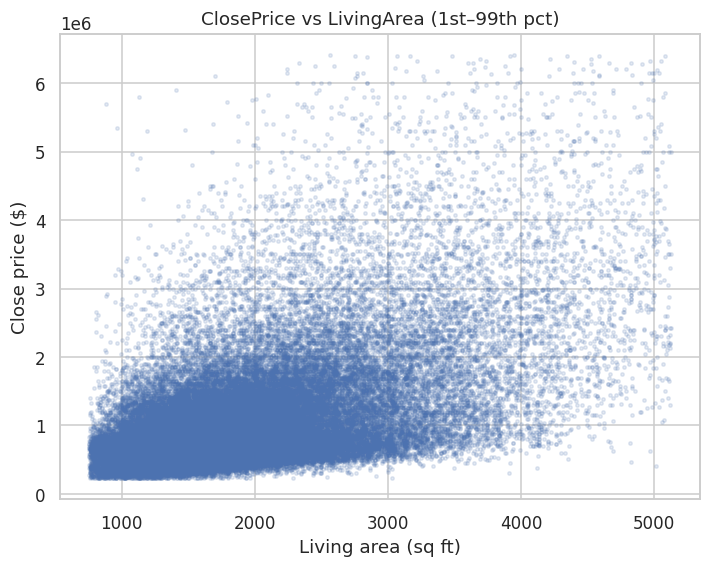

In [14]:
plot_df = eda.copy()
plot_df = plot_df[(plot_df["ClosePrice"] > 0) & (plot_df["LivingArea"] > 0)]
# clip to 1st-99th pct for readability
for c in ["ClosePrice", "LivingArea"]:
    lo, hi = plot_df[c].quantile([0.01, 0.99])
    plot_df = plot_df[plot_df[c].between(lo, hi)]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(plot_df["LivingArea"], plot_df["ClosePrice"], s=5, alpha=0.15, color="#4C72B0")
ax.set_xlabel("Living area (sq ft)")
ax.set_ylabel("Close price ($)")
ax.set_title("ClosePrice vs LivingArea (1st–99th pct)")
plt.show()


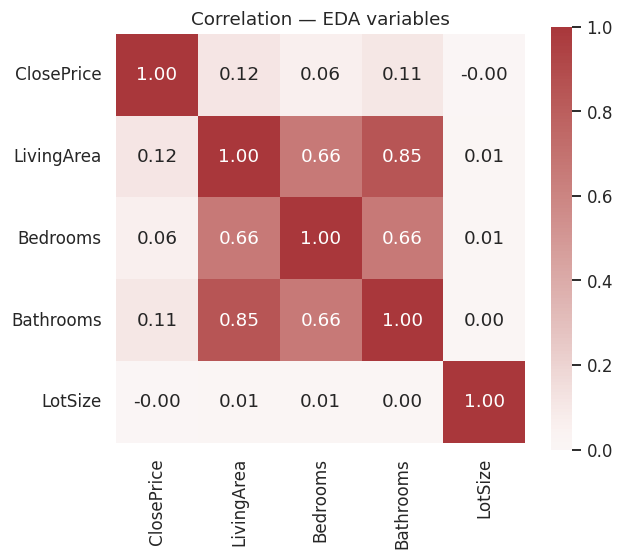

ClosePrice    1.00
LivingArea    0.12
Bathrooms     0.11
Bedrooms      0.06
LotSize      -0.00
Name: ClosePrice, dtype: float64

In [15]:
corr = eda.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Correlation — EDA variables")
plt.show()
corr["ClosePrice"].sort_values(ascending=False)


## 

- **Sample:** ~61.7k single-family residential sales over Dec 2025 – May 2026
  after applying the `Residential` / `SingleFamilyResidence` filter.
- **`ClosePrice`** is strongly right-skewed with a long luxury tail; a log
  transform (or robust/quantile handling) will help downstream modeling.
- **`LivingArea`** and **`LotSize`** are likewise right-skewed and contain
  clearly invalid extremes (0 sq ft, multi-acre "lots") that warrant cleaning.
- **`Bedrooms` / `Bathrooms`** cluster at 3–4 bed / 2–3 bath, with rare high
  counts.
- `LivingArea` shows the strongest positive association with `ClosePrice`.

**Next step:** data cleaning / outlier handling and feature engineering
(`02_*`).

---
#  Identifying features that could influence `ClosePrice`


## Build the analysis frame

In [16]:
import warnings
warnings.filterwarnings("ignore")

work = df.copy()
y = pd.to_numeric(work["ClosePrice"], errors="coerce")
work = work[y > 0].copy()
y = y[y > 0]
logy = np.log10(y)
print(f"Rows used for feature analysis: {len(work):,}")


Rows used for feature analysis: 61,727


##  Data-quality screen

Several RESO columns are unpopulated for the single-family segment in this
extract, so they carry no signal and should be dropped before any modeling.

In [17]:
candidate_cols = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "YearBuilt", "GarageSpaces", "CoveredSpaces", "ParkingTotal", "Stories",
    "FireplacesTotal", "TaxAnnualAmount", "AssociationFee", "DaysOnMarket",
    "Latitude", "Longitude", "AboveGradeFinishedArea", "BuildingAreaTotal",
    "MainLevelBedrooms", "ListPrice", "OriginalListPrice",
    "ViewYN", "WaterfrontYN", "PoolPrivateYN", "BasementYN", "AttachedGarageYN",
    "FireplaceYN", "NewConstructionYN",
    "City", "CountyOrParish", "PostalCode", "MLSAreaMajor",
    "HighSchoolDistrict", "Levels", "SubdivisionName",
]
candidate_cols = [c for c in candidate_cols if c in work.columns]

miss = work[candidate_cols].isna().mean().mul(100).round(1).sort_values(ascending=False)
empty = miss[miss >= 90].index.tolist()
print("Columns >=90% missing in this segment (drop):")
print(miss[miss >= 90].to_string())
usable = [c for c in candidate_cols if c not in empty]
print(f"\nUsable candidate features: {len(usable)}")


Columns >=90% missing in this segment (drop):
FireplacesTotal          100.00
AboveGradeFinishedArea   100.00
CoveredSpaces            100.00
TaxAnnualAmount          100.00
WaterfrontYN              99.90
BasementYN                97.60
BuildingAreaTotal         93.40

Usable candidate features: 27


## Numeric features — correlation with price

In [19]:
num_feats = [c for c in usable
             if c not in LEAKAGE and not c.endswith("YN")
             and work[c].dtype != object]
# coerce + keep only the genuinely numeric ones
rows = []
for c in num_feats:
    x = pd.to_numeric(work[c], errors="coerce")
    if x.notna().sum() < 1000:
        continue
    rows.append({
        "feature": c,
        "n_nonnull": int(x.notna().sum()),
        "pearson": x.corr(y),
        "spearman": x.corr(y, method="spearman"),
        "pearson_logprice": x.corr(logy),
    })
num_corr = (pd.DataFrame(rows)
            .assign(abs_spearman=lambda d: d["spearman"].abs())
            .sort_values("abs_spearman", ascending=False)
            .drop(columns="abs_spearman")
            .reset_index(drop=True))
display(num_corr.round(3))


,feature,n_nonnull,pearson,spearman,pearson_logprice
0,LivingArea,61697,0.12,0.52,0.59
1,BathroomsTotalInteger,61726,0.11,0.48,0.57
2,BedroomsTotal,61727,0.06,0.37,0.40
3,Stories,55234,0.03,0.27,0.27
4,GarageSpaces,59374,0.01,0.24,0.07
5,Longitude,61718,-0.01,-0.23,-0.08
6,AssociationFee,44111,0.04,0.22,0.22
7,ParkingTotal,61727,0.00,0.20,0.01
8,Latitude,61718,-0.01,-0.14,-0.07
9,DaysOnMarket,61727,0.01,-0.12,-0.07


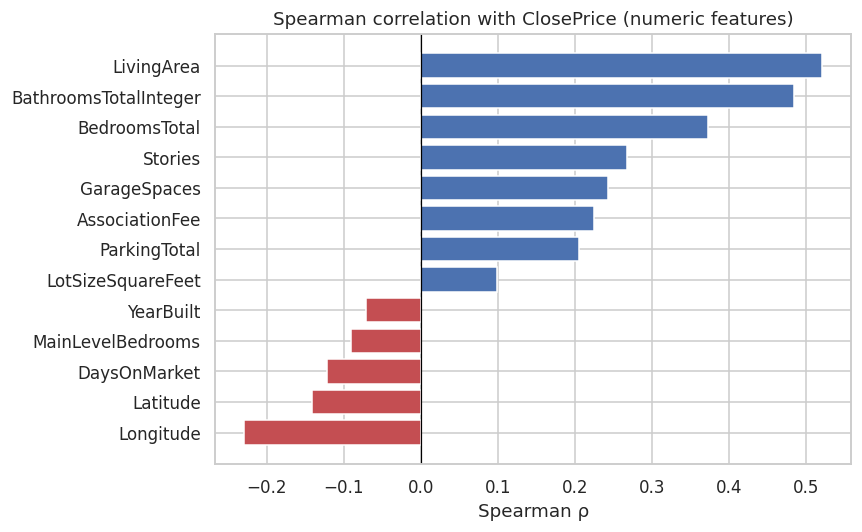

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
order = num_corr.sort_values("spearman")
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in order["spearman"]]
ax.barh(order["feature"], order["spearman"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Spearman correlation with ClosePrice (numeric features)")
ax.set_xlabel("Spearman ρ")
fig.tight_layout()
plt.show()


## Boolean amenity flags

Median sale price split by each yes/no amenity flag; a large gap signals a
useful feature.

In [21]:
bool_feats = [c for c in usable if c.endswith("YN")]
rows = []
for c in bool_feats:
    s = work[c].astype("string").str.strip()
    med = y.groupby(s).median()
    t = med.get("True", np.nan)
    f = med.get("False", np.nan)
    rows.append({
        "flag": c,
        "median_if_true": t,
        "median_if_false": f,
        "premium_x": (t / f) if (pd.notna(t) and pd.notna(f) and f) else np.nan,
        "pct_true": (s == "True").mean() * 100,
    })
bool_tbl = (pd.DataFrame(rows)
            .sort_values("premium_x", ascending=False)
            .reset_index(drop=True))
display(bool_tbl.round(2))


,flag,median_if_true,median_if_false,premium_x,pct_true
0,FireplaceYN,"1,002,000.00","715,000.00",1.40,72.38
1,PoolPrivateYN,"1,150,000.00","825,000.00",1.39,16.89
2,ViewYN,"900,000.00","865,000.00",1.04,62.38
3,AttachedGarageYN,"892,000.00","875,000.00",1.02,83.61
4,NewConstructionYN,"672,314.00","885,000.00",0.76,3.77


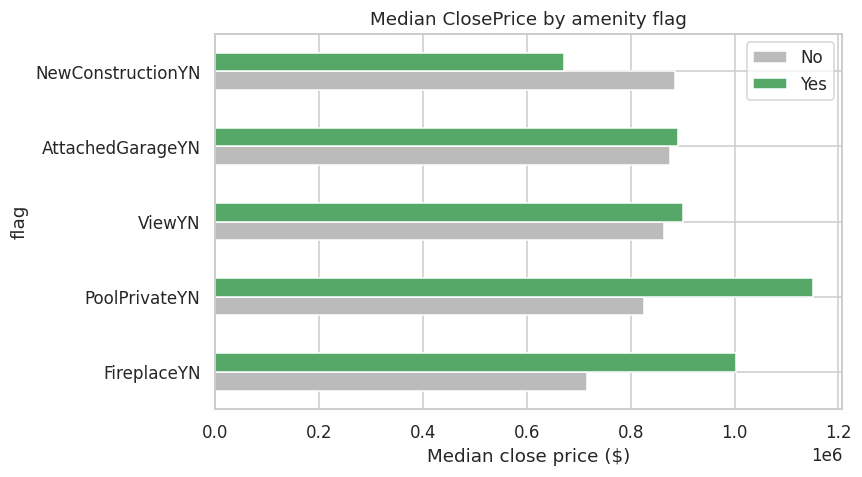

In [22]:
plot_b = bool_tbl.dropna(subset=["median_if_true", "median_if_false"]).set_index("flag")
ax = plot_b[["median_if_false", "median_if_true"]].plot(
    kind="barh", figsize=(8, 4.5), color=["#BBBBBB", "#55A868"])
ax.set_title("Median ClosePrice by amenity flag")
ax.set_xlabel("Median close price ($)")
ax.legend(["No", "Yes"])
plt.tight_layout()
plt.show()


## Location & other categoricals — correlation ratio (η)

Close price varies enormously by *where* the home is. The correlation ratio η
(on log price) summarizes how much of the price variation a categorical field
explains — η near 1 means the field is highly predictive. Location fields
dominate every structural attribute.

In [23]:
def correlation_ratio(cat_series, values):
    s = cat_series.astype("string")
    m = s.notna() & values.notna()
    s, v = s[m], values[m]
    grand = v.mean()
    ss_tot = ((v - grand) ** 2).sum()
    if ss_tot == 0:
        return np.nan
    ss_between = (v.groupby(s)
                   .agg(["count", "mean"])
                   .eval("count * (mean - @grand) ** 2").sum())
    return np.sqrt(ss_between / ss_tot)

cat_feats = [c for c in usable if work[c].dtype == object]
rows = []
for c in cat_feats:
    rows.append({
        "feature": c,
        "n_categories": work[c].nunique(),
        "eta_logprice": correlation_ratio(work[c], logy),
        "pct_missing": work[c].isna().mean() * 100,
    })
cat_tbl = (pd.DataFrame(rows)
           .sort_values("eta_logprice", ascending=False)
           .reset_index(drop=True))
display(cat_tbl.round(3))


,feature,n_categories,eta_logprice,pct_missing
0,SubdivisionName,5351,0.87,64.56
1,PostalCode,1603,0.86,0.00
2,City,912,0.82,0.02
3,MLSAreaMajor,969,0.80,14.14
4,HighSchoolDistrict,398,0.77,26.94
5,CountyOrParish,58,0.60,0.00
6,Levels,17,0.33,7.49
7,FireplaceYN,2,0.26,0.09
8,PoolPrivateYN,2,0.21,7.83
9,ViewYN,2,0.04,8.58


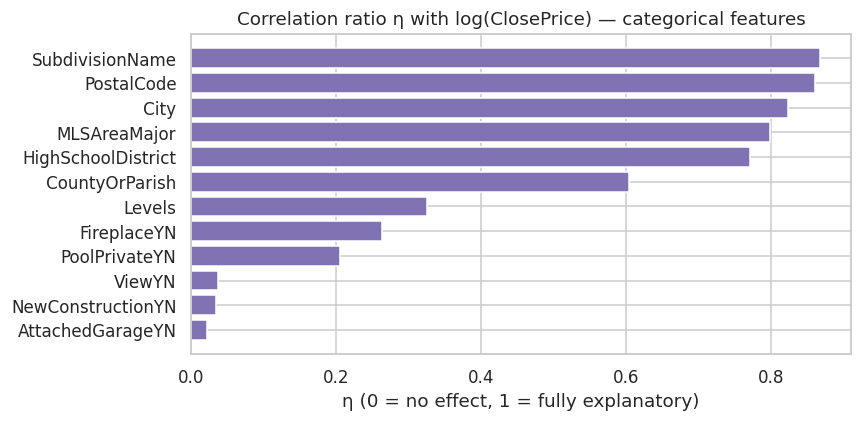

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
o = cat_tbl.sort_values("eta_logprice")
ax.barh(o["feature"], o["eta_logprice"], color="#8172B3")
ax.set_title("Correlation ratio η with log(ClosePrice) — categorical features")
ax.set_xlabel("η (0 = no effect, 1 = fully explanatory)")
fig.tight_layout()
plt.show()


## Mutual information (non-linear) ranking

Mutual information captures non-linear dependence that correlation can miss.
We rank the usable numeric predictors plus a county median-price location
encoding against log price.

,mutual_info
county_median_enc,0.33
Latitude,0.32
Longitude,0.30
LivingArea,0.25
BathroomsTotalInteger,0.20
BedroomsTotal,0.10
LotSizeSquareFeet,0.07
YearBuilt,0.07
AssociationFee,0.06
GarageSpaces,0.05


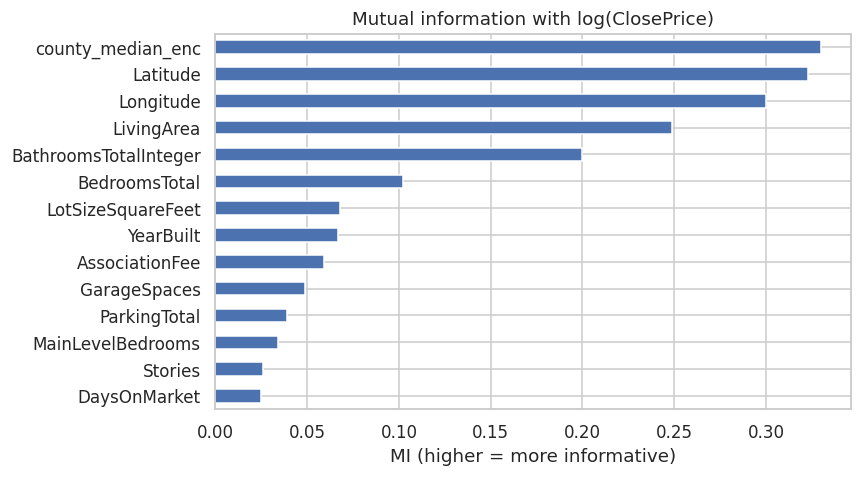

In [25]:
from sklearn.feature_selection import mutual_info_regression

mi_feats = [r["feature"] for _, r in num_corr.iterrows()]
Xmi = work[mi_feats].apply(pd.to_numeric, errors="coerce")
Xmi = Xmi.fillna(Xmi.median())

# add a location encoding: county median close price
county_med = work.groupby("CountyOrParish")["ClosePrice"].transform("median")
Xmi["county_median_enc"] = county_med.fillna(county_med.median())

mi = mutual_info_regression(Xmi, logy, random_state=0)
mi_tbl = (pd.Series(mi, index=Xmi.columns, name="mutual_info")
          .sort_values(ascending=False).round(3))
display(mi_tbl.to_frame())

fig, ax = plt.subplots(figsize=(8, 4.5))
mi_tbl.sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_title("Mutual information with log(ClosePrice)")
ax.set_xlabel("MI (higher = more informative)")
fig.tight_layout()
plt.show()


## Recommended feature set

Bringing the four views together for predicting `ClosePrice` on single-family
homes:

**Strongest, well-populated predictors**
- **Location** — `Latitude`/`Longitude`, `CountyOrParish`, `PostalCode`,
  `City`, `MLSAreaMajor`, `HighSchoolDistrict`. By far the largest driver
  (η ≈ 0.6–0.86; top mutual information). High-cardinality fields should be
  target/median-encoded or grouped rather than one-hot encoded.
- **Size** — `LivingArea` (top structural feature), `BathroomsTotalInteger`,
  `BedroomsTotal`.

**Useful secondary / amenity features**
- `PoolPrivateYN`, `WaterfrontYN`, `BasementYN`, `FireplaceYN`
  (clear price premiums), `GarageSpaces`, `Stories`, `YearBuilt`,
  `AssociationFee`, `LotSizeSquareFeet` (weak linearly but non-zero and
  benefits from log/outlier handling).

**Exclude**
- **Leakage:** `ListPrice`, `OriginalListPrice` (≈ the answer).
- **Empty in this segment:** `TaxAnnualAmount`, `FireplacesTotal`,
  `CoveredSpaces`, `AboveGradeFinishedArea` (≈100% missing); `BuildingAreaTotal`
  (~93% missing) — drop or treat with care.
- **Not price drivers:** identifiers, agent/office names, and free-text fields.

**Modeling notes:** target is right-skewed → model `log(ClosePrice)`;
clean invalid extremes (0-sqft, multi-acre "lots") before fitting; encode
high-cardinality location with target/median encoding + regularization.
